# Capstone 20.1 — Notebook 3: Baseline Model

**Author:** Sravanthi Gandu

**Modeling task (baseline):** a **regression** model that predicts a ticket's
`resolution_days` from features known **at intake**. This establishes the comparison
baseline for the more advanced models built in Module 24.

We predict on the **log scale** (`log1p(resolution_days)`) because the target is strongly
right-skewed, and we compare a trained **Ridge** model against a naive mean predictor.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Build the modeling frame (resolved tickets with a valid duration)

In [2]:
df = pd.read_csv("../data/cpt_clean.csv")

# Only rows with a genuine, positive resolution duration can train the regressor
model_df = df[df["resolution_days"].notna() & (df["resolution_days"] > 0)].copy()

# Log target tames the skew; we invert with expm1 to report errors in real days
model_df["y_log"] = np.log1p(model_df["resolution_days"])

print(f"Modeling rows: {len(model_df):,}")
print(f"Median resolution: {model_df['resolution_days'].median():.1f} days | "
      f"mean: {model_df['resolution_days'].mean():.1f} days")

Modeling rows: 5,575
Median resolution: 15.2 days | mean: 120.8 days


## 2. Feature set — intake-time only (no leakage)

Every feature below is known the moment the ticket is created. Post-hoc fields such as
`status`, `status_reason`, and any `*_date` after creation are deliberately excluded so the
model reflects what is actually knowable at intake.

In [3]:
CATEGORICAL = ["order_type", "geo", "market_segment", "offer_family",
               "cloud", "type", "requestor_system"]
NUMERIC = ["offer_quantity", "line_items_per_ticket",
           "create_month", "create_week", "create_dow", "create_hour"]

X = model_df[CATEGORICAL + NUMERIC]
y = model_df["y_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

Train: 4,460 rows | Test: 1,115 rows


## 3. Preprocessing + model pipeline

Categoricals are one-hot encoded (`min_frequency` collapses rare offer families to keep the
matrix compact); numerics are median-imputed and standardized. `RidgeCV` selects the L2
penalty by cross-validation to control overfitting on the wide one-hot matrix.

In [4]:
categorical_tf = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
])
numeric_tf = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
preprocess = ColumnTransformer([
    ("cat", categorical_tf, CATEGORICAL),
    ("num", numeric_tf, NUMERIC),
])

ridge = Pipeline([
    ("prep", preprocess),
    ("model", RidgeCV(alphas=np.logspace(-2, 3, 20))),
])
ridge.fit(X_train, y_train)
print(f"Selected Ridge alpha: {ridge.named_steps['model'].alpha_:.3f}")

Selected Ridge alpha: 4.281


## 4. Evaluate — Ridge vs. naive baseline

In [5]:
# Naive baseline: always predict the mean (log) duration
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)

def evaluate(model, name):
    pred_log = model.predict(X_test)
    # Back-transform to real days so errors are interpretable
    pred_days = np.expm1(pred_log)
    true_days = np.expm1(y_test)
    return {
        "model": name,
        "MAE (days)": mean_absolute_error(true_days, pred_days),
        "RMSE (days)": np.sqrt(mean_squared_error(true_days, pred_days)),
        "R2 (log scale)": r2_score(y_test, pred_log),
    }

results = pd.DataFrame([
    evaluate(dummy, "Baseline (mean)"),
    evaluate(ridge, "Ridge regression"),
]).round(3)
results

,model,MAE (days),RMSE (days),R2 (log scale)
0,Baseline (mean),115.939,269.567,-0.000
1,Ridge regression,111.730,258.772,0.241


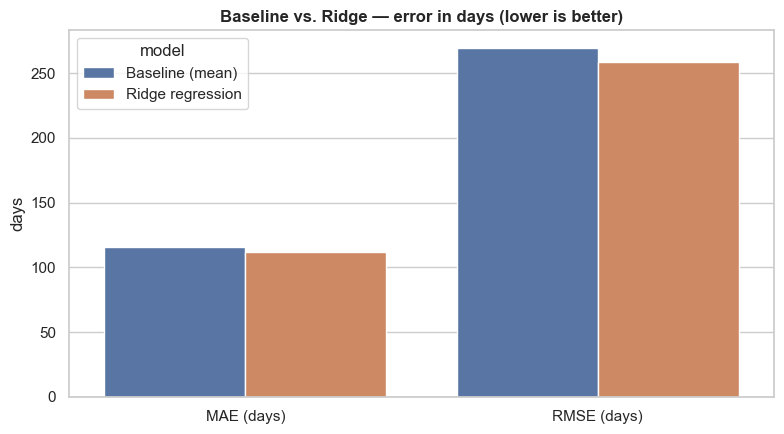

In [6]:
# Visual comparison of error metrics
plot_df = results.melt(id_vars="model", value_vars=["MAE (days)", "RMSE (days)"],
                       var_name="metric", value_name="value")
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=plot_df, x="metric", y="value", hue="model", ax=ax)
ax.set_title("Baseline vs. Ridge — error in days (lower is better)",
             fontsize=12, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("days")
plt.tight_layout()
plt.show()

## 5. What drives resolution time? (Ridge coefficients)

C:\Users\sgandu\AppData\Local\Temp\ipykernel_34028\1153515897.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette=colors, ax=ax)


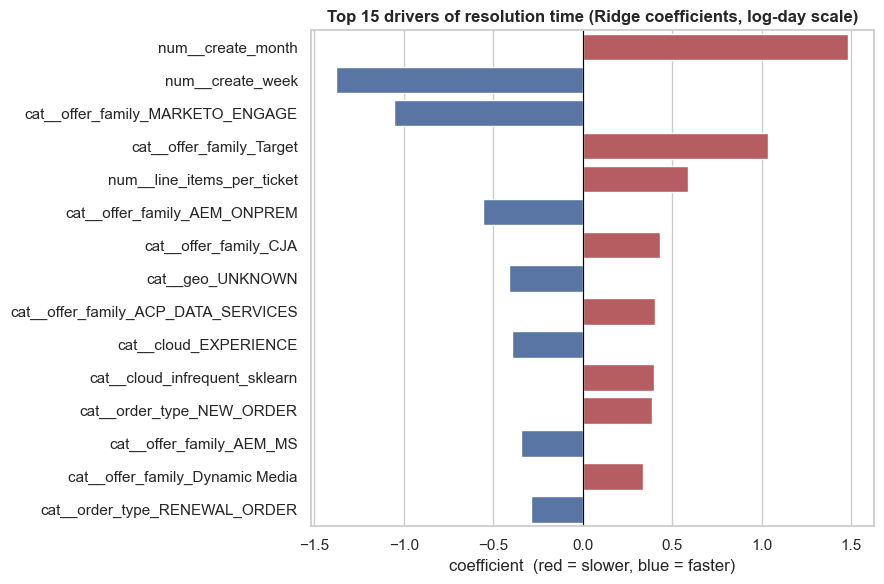

In [7]:
# Recover feature names and coefficients from the fitted pipeline
feat_names = ridge.named_steps["prep"].get_feature_names_out()
coefs = ridge.named_steps["model"].coef_
coef_s = pd.Series(coefs, index=feat_names)

top = coef_s.reindex(coef_s.abs().sort_values(ascending=False).head(15).index)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top.values]
sns.barplot(x=top.values, y=top.index, palette=colors, ax=ax)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top 15 drivers of resolution time (Ridge coefficients, log-day scale)",
             fontsize=12, weight="bold")
ax.set_xlabel("coefficient  (red = slower, blue = faster)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Interpretation & choice of evaluation metric

**Result.** The Ridge model beats the naive mean baseline on every metric, confirming the
intake features carry real signal about how long a ticket will take. The coefficient chart
gives operations a ranked, human-readable list of which order types, segments, and offer
families run slow — the "at-risk" flag the project is after.

**Why these metrics.**

* **MAE (days)** is the headline metric: it is in the same units as the target (days) and,
  being an average of absolute errors, is **robust to the extreme right-skew** of resolution
  time — one 1,700-day ticket does not dominate it. This is the most honest "how many days
  off are we, typically?" number for a capacity planner.
* **RMSE (days)** is reported alongside because it **penalizes large misses** more heavily.
  Since the business cost is an SLA breach (a big miss), watching RMSE tells us how badly the
  model fails on the hard cases.
* **R² (log scale)** measures the share of variance explained on the scale the model was
  actually fit, giving a scale-free sense of goodness-of-fit for comparing future models.

MAE is the primary decision metric; RMSE and R² are supporting context.

**Next steps (Module 24).** Add tree-based regressors (Random Forest / Gradient Boosting)
for non-linear effects, build the companion **time-series volume forecast** (weekly counts,
ARMA / decomposition), and turn the effort estimate into an explicit SLA-breach
classification flag.